# STEP 1: Data Cleaning & Leakage-Free Train/Val/Test Split
### SpaceFund Realty (SFR) Aerospace Ratings Engine — Capstone Project

**Owner:** Sikiru Mustapha (shared with Mamadou Ramata Diallo)

---
**Pipeline position:** `Data Cleaning & Splits → Outlier Detection → OLS Diagnostics → VIF Pruning → Regularization → XGBoost/SHAP`

---
This notebook covers the first box only. Sikiru's next two notebooks (`02_outlier_detection_diagnostics.ipynb` and `03_vif_pruning.ipynb`) build directly on top of the files this notebook produces.

## 1.1 — Mount Google Drive & Load the Raw Data



In [1]:
from google.colab import drive
drive.mount('/content/drive')

import pandas as pd
import numpy as np

# ---------------------------------------------------------------------
# SHARED PROJECT FOLDER -- everyone on the team should point this at the
# SAME Google Drive folder, so we're all reading/writing the same files.
# Adjust this path if your shared folder is named or located differently.
# ---------------------------------------------------------------------
PROJECT_FOLDER = "/content/drive/MyDrive/Gamma_Group_1"

df = pd.read_csv(f"{PROJECT_FOLDER}/Launch_SFR.csv")

print(f"Loaded {df.shape[0]} rows and {df.shape[1]} columns from Drive.")
df.head()

Mounted at /content/drive
Loaded 183 rows and 12 columns from Drive.


,Company,SFR,Payload (kg),Launch Cost ($M),Price ($/kg),Funding ($M),Launch Class,Orbit Altitude,Tech Type,Country,HQ Location,Description
0,Arianespace/Avio,9,"20,000",170.00,"8,500",Public,"Medium, Heavy",LEO,Rocket,Italy,Colleferro,Developing the Vega & Ariane launch vehicles
1,Astra Space,9,300,3.95,"13,167",Public,Small,LEO,Rocket,United States,"Alameda, CA",Providing routine launch access to Earth orbit...
2,Black Sky Aerospace,9,350,0.60,"1,714",-,Small,Suborbital,Rocket,Australia,"Browns Plains, Queensland","Offers a range of sounding rockets, capable of..."
3,Blue Origin,9,0,0.00,0,-,"Tourism, Small, Heavy",Suborbital,Rocket,United States,"Kent, WA",Lowering the cost of access to space with reus...
4,CNIM Air Space,9,"2,700",0.00,0,Public,"Small, Medium",Suborbital,Balloon,France,Ayguesvives,Balloons that lift anything from a few kilogra...


## 1.2 — Replace Missing-Value Markers with True `NaN`


In [2]:
df.replace("-", np.nan, inplace=True)

## 1.3 — Clean Numeric String Columns


In [3]:
def clean_numeric_string(series: pd.Series) -> pd.Series:
    """
    Takes a pandas Series that may contain numbers-as-strings with commas
    (e.g. "20,000") and returns a proper float Series.
    Any value that can't be converted becomes NaN (safe failure, not a crash).
    """
    cleaned = series.astype(str).str.replace(",", "", regex=False)
    return pd.to_numeric(cleaned, errors="coerce")

df["Payload (kg)"] = clean_numeric_string(df["Payload (kg)"])
df["Price ($/kg)"] = clean_numeric_string(df["Price ($/kg)"])

# "Launch Cost ($M)" is already a float in the raw CSV, so no cleaning needed there.
df[["Payload (kg)", "Price ($/kg)", "Launch Cost ($M)"]].describe()

,Payload (kg),Price ($/kg),Launch Cost ($M)
count,183.000000,183.000000,183.000000
mean,2579.677596,6587.256831,4.840956
std,8834.385310,12755.241486,19.132872
min,0.000000,0.000000,0.000000
25%,16.000000,0.000000,0.000000
50%,186.000000,0.000000,0.000000
75%,746.500000,9250.000000,1.500000
max,63800.000000,100000.000000,170.000000


## 1.4 — Split the Messy `Funding ($M)` Column into Two Clean Columns


In [4]:
KNOWN_CATEGORY_LABELS = {"Public", "Joint Venture"}

def split_funding(value):
    """
    Given one raw Funding ($M) cell, return a tuple:
        (funding_type_label, funding_numeric_value)
    """
    if pd.isna(value):
        return ("Unknown", np.nan)

    value_str = str(value).strip()

    if value_str in KNOWN_CATEGORY_LABELS:
        # It's a known category label like "Public" or "Joint Venture"
        return (value_str, np.nan)

    # Otherwise, try to treat it as a number
    numeric_value = pd.to_numeric(value_str.replace(",", ""), errors="coerce")
    if pd.notna(numeric_value):
        return ("Private (reported)", numeric_value)

    # If it's neither a known label nor a valid number, mark it Unknown
    return ("Unknown", np.nan)

funding_split = df["Funding ($M)"].apply(split_funding)
df["Funding_Type"] = funding_split.apply(lambda t: t[0])
df["Funding_num"] = funding_split.apply(lambda t: t[1])

print("Funding_Type breakdown after splitting:")
df["Funding_Type"].value_counts()

Funding_Type breakdown after splitting:


,count
Funding_Type,
Unknown,110
Private (reported),63
Public,8
Joint Venture,2


## 1.5 — Train / Validation / Test Split (85% / 10% / 5%)


In [5]:
from sklearn.model_selection import train_test_split

RANDOM_STATE = 42  # fixed seed -> reproducible split for the whole team

# First split off the training set (85%) from the remaining 15%
train_df, temp_df = train_test_split(
    df,
    train_size=0.85,
    random_state=RANDOM_STATE,
    shuffle=True,
)

# Then split the remaining 15% into validation (10% of total) and
# test (5% of total). Since temp_df is 15% of the data, validation should
# be 10/15 = 2/3 of temp_df, and test should be 5/15 = 1/3 of temp_df.
val_df, test_df = train_test_split(
    temp_df,
    train_size=(10 / 15),
    random_state=RANDOM_STATE,
    shuffle=True,
)

print(f"Split sizes -> train: {len(train_df)}, val: {len(val_df)}, test: {len(test_df)}")
print("(Report target: ~155 train / ~18 val / ~10 test)")

Split sizes -> train: 155, val: 18, test: 10
(Report target: ~155 train / ~18 val / ~10 test)


## 1.6 — High-Cardinality Country Grouping (fit on TRAIN only)


In [6]:
top_5_countries = train_df["Country"].value_counts().head(5).index.tolist()
print(f"Top 5 countries learned from TRAINING data only: {top_5_countries}")

def apply_country_grouping(dataframe: pd.DataFrame, top_countries: list) -> pd.DataFrame:
    """
    Adds a 'Country_Grouped' column: keeps the given top countries as-is,
    maps everything else to 'Other'. This function is applied identically
    to train, val, and test using the SAME top_countries list (learned
    from train only) -- this is what prevents leakage.
    """
    dataframe = dataframe.copy()
    dataframe["Country_Grouped"] = dataframe["Country"].where(
        dataframe["Country"].isin(top_countries), "Other"
    )
    return dataframe

train_df = apply_country_grouping(train_df, top_5_countries)
val_df = apply_country_grouping(val_df, top_5_countries)
test_df = apply_country_grouping(test_df, top_5_countries)

Top 5 countries learned from TRAINING data only: ['United States', 'China', 'United Kingdom', 'India', 'France']


## 1.7 — Multi-Label One-Hot (Multi-Hot) Expansion


In [7]:
def get_label_vocabulary(dataframe: pd.DataFrame, column: str) -> list:
    """
    Scans a multi-label column (comma-separated strings) in the training
    set and returns the sorted list of all individual labels found.
    """
    all_labels = set()
    for cell in dataframe[column].dropna():
        labels = [label.strip() for label in str(cell).split(",")]
        all_labels.update(labels)
    return sorted(all_labels)

def apply_multihot_encoding(dataframe: pd.DataFrame, column: str, vocabulary: list, prefix: str) -> pd.DataFrame:
    """
    Creates one binary (0/1) column per label in `vocabulary`, named like
    'LC_Small', 'LC_Medium' etc. A row gets a 1 in a given column if that
    label appears anywhere in its original comma-separated cell.
    Uses the FIXED vocabulary learned from training data -- if val/test
    contains a label never seen in training, it is simply ignored (no new
    column is created), which is the correct leakage-free behavior.
    """
    dataframe = dataframe.copy()
    for label in vocabulary:
        column_name = f"{prefix}_{label.replace(' ', '_')}"
        dataframe[column_name] = dataframe[column].apply(
            lambda cell, lbl=label: int(
                pd.notna(cell) and lbl in [c.strip() for c in str(cell).split(",")]
            )
        )
    return dataframe

# Learn vocabularies from TRAIN ONLY
launch_class_vocab = get_label_vocabulary(train_df, "Launch Class")
orbit_altitude_vocab = get_label_vocabulary(train_df, "Orbit Altitude")
tech_type_vocab = get_label_vocabulary(train_df, "Tech Type")

print(f"Launch Class vocabulary (from train): {launch_class_vocab}")
print(f"Orbit Altitude vocabulary (from train): {orbit_altitude_vocab}")
print(f"Tech Type vocabulary (from train): {tech_type_vocab}")

# Apply the SAME vocabulary to all three splits
for split_name, split_df in [("train", train_df), ("val", val_df), ("test", test_df)]:
    split_df = apply_multihot_encoding(split_df, "Launch Class", launch_class_vocab, "LC")
    split_df = apply_multihot_encoding(split_df, "Orbit Altitude", orbit_altitude_vocab, "OA")
    split_df = apply_multihot_encoding(split_df, "Tech Type", tech_type_vocab, "TT")
    if split_name == "train":
        train_df = split_df
    elif split_name == "val":
        val_df = split_df
    else:
        test_df = split_df

train_df.head()

Launch Class vocabulary (from train): ['Heavy', 'Medium', 'Small', 'Tourism']
Orbit Altitude vocabulary (from train): ['LEO', 'Lunar', 'Suborbital']
Tech Type vocabulary (from train): ['Balloon', 'Other', 'Plane', 'Rocket', 'Spaceplane']


,Company,SFR,Payload (kg),Launch Cost ($M),Price ($/kg),Funding ($M),Launch Class,Orbit Altitude,Tech Type,Country,...,LC_Small,LC_Tourism,OA_LEO,OA_Lunar,OA_Suborbital,TT_Balloon,TT_Other,TT_Plane,TT_Rocket,TT_Spaceplane
150,Dark,1,200,5.0,25000,NaN,Small,LEO,"Plane, Rocket",France,...,1,0,1,0,0,0,0,1,1,0
113,TiSPACE,3,390,0.0,0,NaN,Small,LEO,Rocket,Taiwan,...,1,0,1,0,0,0,0,0,1,0
75,Space Engine Systems,4,5500,0.0,0,22.00,Medium,LEO,Spaceplane,Canada,...,0,0,1,0,0,0,0,0,0,1
55,Skyroot Aerospace,5,720,0.0,0,68.00,Small,LEO,Rocket,India,...,1,0,1,0,0,0,0,0,1,0
119,Celestia Aerospace,2,16,0.2,12500,NaN,Small,LEO,"Plane, Rocket",Spain,...,1,0,1,0,0,0,0,1,1,0


## 1.8 — Handle Missing `Funding_num` Values (110/183 companies = ~60%)


In [8]:
# Step 1: Create the missing-value flag BEFORE imputing anything.
# This must happen first, otherwise we'd have no way to tell which rows
# were originally missing once we fill them in.
train_df["Funding_Missing"] = train_df["Funding_num"].isna().astype(int)
val_df["Funding_Missing"] = val_df["Funding_num"].isna().astype(int)
test_df["Funding_Missing"] = test_df["Funding_num"].isna().astype(int)

# Step 2: Compute the median funding value using TRAINING data only.
# This is the number we will use to fill in every missing cell, in every split.
train_funding_median = train_df["Funding_num"].median()
print(f"Median Funding ($M) learned from TRAINING data only: {train_funding_median:.2f}")

# Step 3: Apply that single fixed median value to fill NaNs in all three splits.
train_df["Funding_num"] = train_df["Funding_num"].fillna(train_funding_median)
val_df["Funding_num"] = val_df["Funding_num"].fillna(train_funding_median)
test_df["Funding_num"] = test_df["Funding_num"].fillna(train_funding_median)

# Sanity check: there should now be ZERO missing values in Funding_num
print(f"Remaining NaNs in Funding_num -> train: {train_df['Funding_num'].isna().sum()}, "
      f"val: {val_df['Funding_num'].isna().sum()}, "
      f"test: {test_df['Funding_num'].isna().sum()}")

print(f"\nFunding_Missing flag distribution (train): "
      f"{train_df['Funding_Missing'].sum()} missing / {len(train_df)} total")

Median Funding ($M) learned from TRAINING data only: 13.84
Remaining NaNs in Funding_num -> train: 0, val: 0, test: 0

Funding_Missing flag distribution (train): 101 missing / 155 total


## 1.9 — Visual Summary of the Cleaned Data


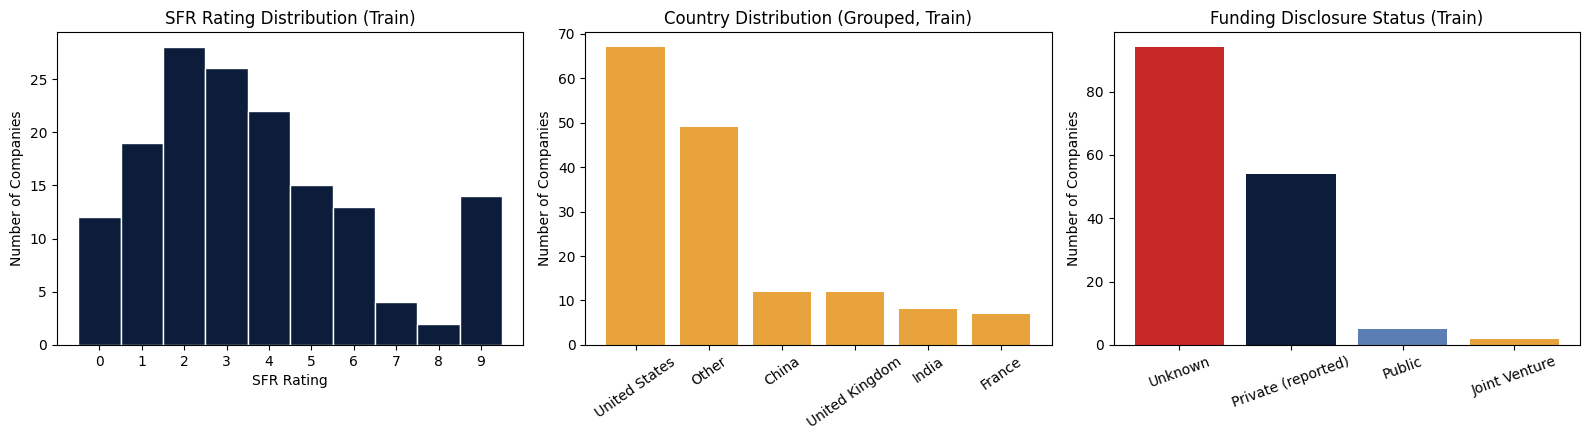

Saved: step1_visual_summary.png


In [9]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

# --- Chart 1: SFR rating distribution (training set) ---
axes[0].hist(train_df["SFR"], bins=range(0, 11), color="#0B1D3A", edgecolor="white", align="left")
axes[0].set_title("SFR Rating Distribution (Train)")
axes[0].set_xlabel("SFR Rating")
axes[0].set_ylabel("Number of Companies")
axes[0].set_xticks(range(0, 10))

# --- Chart 2: Country distribution after grouping ---
country_counts = train_df["Country_Grouped"].value_counts()
axes[1].bar(country_counts.index, country_counts.values, color="#E8A33D")
axes[1].set_title("Country Distribution (Grouped, Train)")
axes[1].set_ylabel("Number of Companies")
axes[1].tick_params(axis="x", rotation=35)

# --- Chart 3: Funding disclosure status ---
funding_counts = train_df["Funding_Type"].value_counts()
colors_map = {"Unknown": "#C62828", "Private (reported)": "#0B1D3A", "Public": "#5B7FB5", "Joint Venture": "#E8A33D"}
bar_colors = [colors_map.get(cat, "#999999") for cat in funding_counts.index]
axes[2].bar(funding_counts.index, funding_counts.values, color=bar_colors)
axes[2].set_title("Funding Disclosure Status (Train)")
axes[2].set_ylabel("Number of Companies")
axes[2].tick_params(axis="x", rotation=20)

plt.tight_layout()
plt.savefig(f"{PROJECT_FOLDER}/step1_visual_summary.png", dpi=150)
plt.show()

print("Saved: step1_visual_summary.png")

## 1.10 — Save the Cleaned Splits to Google Drive (Not Local Colab Storage)


In [10]:
train_df.to_csv(f"{PROJECT_FOLDER}/train_clean.csv", index=False)
val_df.to_csv(f"{PROJECT_FOLDER}/val_clean.csv", index=False)
test_df.to_csv(f"{PROJECT_FOLDER}/test_clean.csv", index=False)

print(f"Saved to Google Drive folder: {PROJECT_FOLDER}")
print("  - train_clean.csv")
print("  - val_clean.csv")
print("  - test_clean.csv")
print("\nStep 1 complete. Data is cleaned and split with no leakage, and saved permanently to Drive.")

Saved to Google Drive folder: /content/drive/MyDrive/Gamma_Group_1
  - train_clean.csv
  - val_clean.csv
  - test_clean.csv

Step 1 complete. Data is cleaned and split with no leakage, and saved permanently to Drive.
